In [13]:
"""
WSOD with Dedicated Spatial Attention Module
Freezes backbone, trains only spatial attention layer + FC
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
import timm
import cv2

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [14]:
# ============================================================================
# Spatial Attention Module
# ============================================================================

class SpatialAttentionModule(nn.Module):
    """
    Learnable spatial attention module
    Takes features from backbone and outputs spatial attention weights
    """
    def __init__(self, in_channels=2048, reduction=8):
        super(SpatialAttentionModule, self).__init__()
        
        # Spatial attention pathway
        self.conv1 = nn.Conv2d(in_channels, in_channels // reduction, kernel_size=1)
        self.bn1 = nn.BatchNorm2d(in_channels // reduction)
        self.relu = nn.ReLU(inplace=True)
        
        self.conv2 = nn.Conv2d(in_channels // reduction, in_channels // reduction, 
                               kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(in_channels // reduction)
        
        # Output attention map
        self.conv_out = nn.Conv2d(in_channels // reduction, 1, kernel_size=1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        """
        Args:
            x: [B, 2048, 7, 7] features from backbone
        Returns:
            attention: [B, 1, 7, 7] spatial attention map
            weighted_features: [B, 2048, 7, 7] attention-weighted features
        """
        # Generate spatial attention
        att = self.conv1(x)
        att = self.bn1(att)
        att = self.relu(att)
        
        att = self.conv2(att)
        att = self.bn2(att)
        att = self.relu(att)
        
        att = self.conv_out(att)
        attention = self.sigmoid(att)  # [B, 1, 7, 7]
        
        # Apply attention to features
        weighted_features = x * attention
        
        return attention, weighted_features

In [15]:
# ============================================================================
# WSOD Model with Spatial Attention
# ============================================================================

class WSODModelWithAttention(nn.Module):
    def __init__(self, base_model, num_classes=2, freeze_backbone=True):
        super(WSODModelWithAttention, self).__init__()
        
        # Freeze backbone if requested
        if freeze_backbone:
            for param in base_model.parameters():
                param.requires_grad = False
            print("✓ Backbone frozen")
        
        # Extract feature extractor (everything except FC)
        self.features = nn.Sequential(*list(base_model.children())[:-2])  # Up to layer4
        self.avgpool = list(base_model.children())[-2]  # AdaptiveAvgPool2d
        
        # Add spatial attention module (TRAINABLE)
        self.spatial_attention = SpatialAttentionModule(in_channels=2048)
        
        # Classifier head (TRAINABLE)
        self.fc = nn.Linear(2048, num_classes)
        
        # If backbone is frozen, unfreeze only the FC from base_model
        if freeze_backbone:
            # Copy weights from original FC if available
            original_fc = list(base_model.children())[-1]
            if isinstance(original_fc, nn.Linear):
                self.fc.weight.data.copy_(original_fc.weight.data)
                self.fc.bias.data.copy_(original_fc.bias.data)
        
    def forward(self, x, return_attention=False):
        # Extract features from frozen backbone
        features = self.features(x)  # [B, 2048, 7, 7]
        
        # Apply spatial attention
        attention_map, weighted_features = self.spatial_attention(features)
        
        # Global average pooling
        pooled = self.avgpool(weighted_features)  # [B, 2048, 1, 1]
        pooled = pooled.flatten(1)  # [B, 2048]
        
        # Classification
        output = self.fc(pooled)
        
        if return_attention:
            return output, attention_map
        return output
    
    def get_attention_map(self, x):
        """Get spatial attention map for visualization"""
        with torch.no_grad():
            features = self.features(x)
            attention_map, _ = self.spatial_attention(features)
        return attention_map

In [16]:
# ============================================================================
# Attention-based Loss Functions
# ============================================================================

def bbox_to_gaussian_mask(bbox, target_size=(7, 7), sigma_scale=1.0):
    """
    Convert bounding box to Gaussian mask for soft attention guidance
    """
    batch_size = bbox.shape[0]
    h, w = target_size
    
    # Create coordinate grids
    y_coords = torch.linspace(0, 1, h, device=bbox.device).view(-1, 1).expand(h, w)
    x_coords = torch.linspace(0, 1, w, device=bbox.device).view(1, -1).expand(h, w)
    
    masks = []
    for i in range(batch_size):
        x, y, box_w, box_h = bbox[i]
        
        # Center of bounding box
        cx = x + box_w / 2
        cy = y + box_h / 2
        
        # Sigma based on box size
        sigma_x = (box_w / 2) * sigma_scale
        sigma_y = (box_h / 2) * sigma_scale
        
        # Prevent division by zero
        sigma_x = max(sigma_x, 0.05)
        sigma_y = max(sigma_y, 0.05)
        
        # Gaussian formula
        gaussian = torch.exp(
            -((x_coords - cx) ** 2) / (2 * sigma_x ** 2) -
            ((y_coords - cy) ** 2) / (2 * sigma_y ** 2)
        )
        
        masks.append(gaussian)
    
    return torch.stack(masks).unsqueeze(1)  # [B, 1, H, W]


def spatial_attention_loss(attention_map, bbox, label, sigma_scale=1.0):
    """
    Direct supervision for spatial attention module
    Only applied to positive samples (nodules present)
    """
    # Only compute loss for positive samples
    positive_mask = label == 1
    
    if positive_mask.sum() == 0:
        return torch.tensor(0.0, device=attention_map.device)
    
    # Get positive samples
    pos_attention = attention_map[positive_mask]
    pos_bbox = bbox[positive_mask]
    
    # Generate Gaussian masks from bboxes (at native resolution 7x7)
    target_size = (pos_attention.shape[2], pos_attention.shape[3])
    gaussian_masks = bbox_to_gaussian_mask(pos_bbox, target_size, sigma_scale)
    
    # MSE loss between attention and Gaussian mask
    mse_loss = F.mse_loss(pos_attention, gaussian_masks)
    
    # KL divergence loss (treating as probability distributions)
    attention_prob = pos_attention / (pos_attention.sum(dim=(2, 3), keepdim=True) + 1e-8)
    target_prob = gaussian_masks / (gaussian_masks.sum(dim=(2, 3), keepdim=True) + 1e-8)
    
    kl_loss = F.kl_div(
        (attention_prob + 1e-8).log(), 
        target_prob, 
        reduction='batchmean'
    )
    
    # Combine losses
    total_loss = 0.5 * mse_loss + 0.5 * kl_loss
    
    return total_loss

In [17]:
# ============================================================================
# Training Functions
# ============================================================================

def train_epoch_wsod(model, loader, criterion, optimizer, device, attention_weight=0.5, sigma_scale=1.0):
    model.train()
    running_loss = 0.0
    running_cls_loss = 0.0
    running_att_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    all_probs = []
    
    pbar = tqdm(loader, desc='Training WSOD')
    for images, labels, bboxes in pbar:
        images, labels, bboxes = images.to(device), labels.to(device), bboxes.to(device)
        
        optimizer.zero_grad()
        
        # Forward pass with attention
        outputs, attention_map = model(images, return_attention=True)
        
        # Classification loss
        cls_loss = criterion(outputs, labels)
        
        # Spatial attention loss (direct supervision on attention module)
        att_loss = spatial_attention_loss(attention_map, bboxes, labels, sigma_scale)
        
        # Total loss
        loss = cls_loss + attention_weight * att_loss
        
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        running_loss += loss.item()
        running_cls_loss += cls_loss.item()
        running_att_loss += att_loss.item()
        
        probs = torch.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().detach().numpy())
        
        pbar.set_postfix({
            'loss': running_loss/len(pbar),
            'cls': running_cls_loss/len(pbar),
            'att': running_att_loss/len(pbar),
            'acc': 100.*correct/total
        })
    
    epoch_loss = running_loss / len(loader)
    epoch_cls_loss = running_cls_loss / len(loader)
    epoch_att_loss = running_att_loss / len(loader)
    epoch_acc = 100. * correct / total
    
    return epoch_loss, epoch_cls_loss, epoch_att_loss, epoch_acc, all_preds, all_labels, all_probs


def validate_wsod(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels, bboxes in tqdm(loader, desc='Validation'):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            probs = torch.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)
            
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    
    binary_precision = precision_score(all_labels, all_preds, average='binary', zero_division=0)
    binary_recall = recall_score(all_labels, all_preds, average='binary', zero_division=0)
    binary_f1 = f1_score(all_labels, all_preds, average='binary', zero_division=0)
    binary_auc = roc_auc_score(all_labels, all_probs)
    
    return epoch_loss, epoch_acc, all_preds, all_labels, all_probs, binary_precision, binary_recall, binary_f1, binary_auc


In [18]:
# ============================================================================
# Visualization Functions
# ============================================================================

def visualize_attention_with_bbox(model, image, bboxes, label, pred, denormalize=True):
    """
    Visualize attention map overlaid on image with GT bbox(es)
    """
    model.eval()
    
    # Denormalize image
    if denormalize:
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        image_display = image.cpu() * std + mean
        image_display = image_display.clamp(0, 1)
    else:
        image_display = image.cpu()
    
    # Get attention map
    with torch.no_grad():
        attention_map = model.get_attention_map(image.unsqueeze(0).to(device))
        attention_map = attention_map.squeeze().cpu().numpy()
    
    # Resize attention to match image
    attention_resized = cv2.resize(attention_map, (224, 224))
    
    # Create figure
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Original image
    img_np = image_display.permute(1, 2, 0).numpy()
    axes[0].imshow(img_np)
    axes[0].set_title(f'Original\nGT: {label}, Pred: {pred}')
    axes[0].axis('off')
    
    # Attention heatmap
    axes[1].imshow(img_np)
    im = axes[1].imshow(attention_resized, cmap='jet', alpha=0.5)
    axes[1].set_title('Spatial Attention')
    axes[1].axis('off')
    plt.colorbar(im, ax=axes[1], fraction=0.046)
    
    # With bounding box(es)
    axes[2].imshow(img_np)
    axes[2].imshow(attention_resized, cmap='jet', alpha=0.5)
    
    # Draw bbox(es) if nodule is present
    if label == 1:
        if not isinstance(bboxes, list):
            bboxes = [bboxes]
        
        for idx, bbox in enumerate(bboxes):
            x, y, w, h = bbox.cpu().numpy()
            x_pix = x * 224
            y_pix = y * 224
            w_pix = w * 224
            h_pix = h * 224
            
            color = 'lime'
            rect = plt.Rectangle(
                (x_pix, y_pix), w_pix, h_pix,
                fill=False, edgecolor=color, linewidth=2
            )
            axes[2].add_patch(rect)
        
        axes[2].legend([f'GT BBox ({len(bboxes)} nodule{"s" if len(bboxes) > 1 else ""})'])
    
    axes[2].set_title('Attention + GT BBox')
    axes[2].axis('off')
    
    plt.tight_layout()
    return fig

print("=" * 80)
print("Setup complete with Spatial Attention Module!")
print("=" * 80)

Setup complete with Spatial Attention Module!


In [19]:
# ============================================================================
# CONFIGURATION
# ============================================================================

BATCH_SIZE = 16
NUM_EPOCHS = 30  # More epochs since attention module learns from scratch
LEARNING_RATE = 3e-4  # Higher LR for attention module (backbone is frozen)
IMAGE_SIZE = 224
NUM_WORKERS = 8
WEIGHT_DECAY = 0.01
ATTENTION_WEIGHT = 1.0  # Can be higher since backbone is safe
SIGMA_SCALE = 1.5  # Start strict, can adjust if needed

# Paths
split_base_path = "./dataset_nodule21/cxr_images/proccessed_data/split_data"
checkpoint_path = "./resnet50_binary.pth"

train_images_path = f"{split_base_path}/train/images"
val_images_path = f"{split_base_path}/val/images"
test_images_path = f"{split_base_path}/test/images"

train_csv_path = f"{split_base_path}/train/metadata_no_aug.csv"
val_csv_path = f"{split_base_path}/val/metadata_val.csv"
test_csv_path = f"{split_base_path}/test/metadata_test.csv"

In [20]:
# ============================================================================
# LOAD DATA
# ============================================================================

print("\nLoading datasets...")
train_df = pd.read_csv(train_csv_path)
val_df = pd.read_csv(val_csv_path)
test_df = pd.read_csv(test_csv_path)

print(f"Train samples: {len(train_df)}")
print(f"Val samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")

# Transforms
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create datasets with bbox
from NoduleDS import NoduleDataset

train_dataset = NoduleDataset(train_df, train_images_path, transform=train_transform, return_bbox=True)
val_dataset = NoduleDataset(val_df, val_images_path, transform=val_transform, return_bbox=True)
test_dataset = NoduleDataset(test_df, test_images_path, transform=val_transform, return_bbox=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)



Loading datasets...
Train samples: 3657
Val samples: 782
Test samples: 785


In [21]:
# ==================== LOSS FUNCTIONS ====================

def attention_bbox_loss(attention_map, bbox, label, lambda_att=1.0):
    """
    Encourages attention to overlap with GT bbox for positive samples.
    Only trains the attention branch - classifier is unaffected.
    
    Args:
        attention_map: [B, 1, H, W] attention weights
        bbox: [B, 4] normalized (x, y, w, h) in [0, 1]
        label: [B] binary labels
        lambda_att: weight for attention loss
    """
    B, _, H, W = attention_map.shape
    device = attention_map.device
    
    total_loss = 0.0
    valid_samples = 0
    
    for i in range(B):
        # Only apply to positive samples (label=1)
        if label[i] == 0:
            continue
            
        x, y, w, h = bbox[i]
        
        # Skip invalid bboxes (all zeros = no nodule case)
        if x == 0 and y == 0 and w == 0 and h == 0:
            continue
        
        # Convert normalized bbox to attention map coordinates
        x_center = x + w / 2
        y_center = y + h / 2
        
        # Create Gaussian-like target centered on bbox
        y_grid = torch.linspace(0, 1, H, device=device).view(-1, 1)
        x_grid = torch.linspace(0, 1, W, device=device).view(1, -1)
        
        # Gaussian with sigma proportional to bbox size (with minimum)
        sigma_x = max(w * 1.5, 0.1)  # At least 10% of image
        sigma_y = max(h * 1.5, 0.1)
        
        target = torch.exp(-((x_grid - x_center)**2 / (2 * sigma_x**2) + 
                            (y_grid - y_center)**2 / (2 * sigma_y**2)))
        
        # Normalize target
        target = target / (target.sum() + 1e-8)
        
        # MSE between attention and target
        att = attention_map[i, 0]
        att_normalized = att / (att.sum() + 1e-8)
        
        loss = F.mse_loss(att_normalized, target)
        total_loss += loss
        valid_samples += 1
    
    if valid_samples == 0:
        return torch.tensor(0.0, device=device)
    
    return lambda_att * (total_loss / valid_samples)

def calculate_attention_iou(attention_map, bbox, threshold=0.5):
    """
    Calculate IoU between thresholded attention map and ground truth bbox
    
    Args:
        attention_map: [H, W] numpy array of attention weights (0-1)
        bbox: [4] numpy array [x, y, w, h] in normalized coordinates [0, 1]
        threshold: threshold to binarize attention map
    
    Returns:
        iou: Intersection over Union score
    """
    H, W = attention_map.shape
    
    # Binarize attention map
    attention_binary = (attention_map > threshold).astype(np.float32)
    
    # Create bbox mask
    x, y, w, h = bbox
    x1 = int(x * W)
    y1 = int(y * H)
    x2 = int((x + w) * W)
    y2 = int((y + h) * H)
    
    # Clamp to valid range
    x1 = max(0, min(x1, W - 1))
    x2 = max(0, min(x2, W))
    y1 = max(0, min(y1, H - 1))
    y2 = max(0, min(y2, H))
    
    # Create bbox mask
    bbox_mask = np.zeros((H, W), dtype=np.float32)
    bbox_mask[y1:y2, x1:x2] = 1.0
    
    # Calculate IoU
    intersection = np.sum(attention_binary * bbox_mask)
    union = np.sum((attention_binary + bbox_mask) > 0)
    
    if union == 0:
        return 0.0
    
    iou = intersection / union
    return iou


In [22]:
# Updated training function (attention loss only)
def train_epoch_attention_only(model, loader, optimizer, device, lambda_att):
    # Set model to train mode first
    model.train()
    
    # Then freeze specific parts
    for module in model.features.modules():
        module.eval()
        for param in module.parameters():
            param.requires_grad = False
    
    for param in model.fc.parameters():
        param.requires_grad = False
    model.fc.eval()
    
    # Make sure spatial attention is trainable
    model.spatial_attention.train()
    for param in model.spatial_attention.parameters():
        param.requires_grad = True
    
    running_att_loss = 0.0
    all_preds = []
    all_labels = []
    
    pbar = tqdm(loader, desc='Training Attention')
    for images, labels, bboxes in pbar:
        images = images.to(device)
        labels = labels.to(device)
        bboxes = bboxes.to(device)
        
        optimizer.zero_grad()
        
        # Forward
        with torch.no_grad():
            # Get features from frozen backbone
            features = model.features(images)
        
        # Allow gradients for attention module
        features.requires_grad = True
        
        # Apply trainable spatial attention
        attention_map, weighted_features = model.spatial_attention(features)
        
        # Continue forward pass
        pooled = model.avgpool(weighted_features)
        pooled = pooled.flatten(1)
        
        with torch.no_grad():
            logits = model.fc(pooled)
        
        # ONLY attention loss (no classification loss!)
        loss = attention_bbox_loss(attention_map, bboxes, labels, lambda_att)
        
        if loss.requires_grad:
            loss.backward()
            optimizer.step()
        
        running_att_loss += loss.item()
        
        # Track classification (just for monitoring - not training it)
        _, predicted = logits.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        pbar.set_postfix({'att_loss': running_att_loss / (pbar.n + 1)})
    
    acc = 100. * sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
    return running_att_loss / len(loader), acc


def validate_attention(model, loader, device, lambda_att):
    model.eval()
    running_att_loss = 0.0
    all_preds = []
    all_labels = []
    all_ious = []
    
    with torch.no_grad():
        for images, labels, bboxes in tqdm(loader, desc='Validation'):
            images = images.to(device)
            labels = labels.to(device)
            bboxes = bboxes.to(device)
            
            logits, attention_map = model(images, return_attention=True)
            
            # Attention loss
            loss = attention_bbox_loss(attention_map, bboxes, labels, lambda_att)
            running_att_loss += loss.item()
            
            # Track classification
            _, predicted = logits.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
            # Calculate attention IoU for positive samples
            for i in range(images.size(0)):
                if labels[i] == 0:  # Skip negative samples
                    continue
                    
                bbox = bboxes[i].cpu().numpy()
                if bbox[0] == 0 and bbox[1] == 0 and bbox[2] == 0 and bbox[3] == 0:
                    continue
                
                att_map = attention_map[i, 0].cpu().numpy()
                iou = calculate_attention_iou(att_map, bbox, threshold=0.5)
                all_ious.append(iou)
    
    acc = 100. * sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
    mean_iou = np.mean(all_ious) if all_ious else 0.0
    
    return running_att_loss / len(loader), acc, mean_iou

In [23]:
# ============================================================================
# LOAD PRETRAINED MODEL & SETUP WSOD WITH SPATIAL ATTENTION
# ============================================================================

print("\nLoading pretrained checkpoint...")
base_model = timm.create_model('resnet50', pretrained=False, num_classes=2)

# Load checkpoint
checkpoint = torch.load(checkpoint_path, map_location=device)
if 'model_state_dict' in checkpoint:
    base_model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded checkpoint from epoch {checkpoint.get('epoch', 'unknown')}")
    print(f"Previous val_acc: {checkpoint.get('val_acc', 'unknown'):.2f}%")
else:
    base_model.load_state_dict(checkpoint)
    print("Loaded model weights")

# Create model with spatial attention module
# freeze_backbone=True (this already copies FC weights and makes them trainable)
model = WSODModelWithAttention(base_model, num_classes=2, freeze_backbone=True).to(device)

# Now freeze the FC layer separately if you want ONLY attention to be trainable
for param in model.fc.parameters():
    param.requires_grad = False
print("✓ Classifier (FC) frozen")

# Count parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTrainable parameters: {trainable_params:,} / {total_params:,} ({100*trainable_params/total_params:.1f}%)")
print("Only Spatial Attention Module is trainable")

# Optimizer - only spatial attention is trainable
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=3e-4,  # Higher LR since we're only training attention module
    weight_decay=0.01
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

print("\nModel ready for WSOD fine-tuning with Spatial Attention!")
print("NOTE: Classification performance will remain constant (frozen)")


Loading pretrained checkpoint...
Loaded checkpoint from epoch 24
Previous val_acc: 96.68%
✓ Backbone frozen
✓ Classifier (FC) frozen

Trainable parameters: 1,115,905 / 24,628,035 (4.5%)
Only Spatial Attention Module is trainable

Model ready for WSOD fine-tuning with Spatial Attention!
NOTE: Classification performance will remain constant (frozen)


In [24]:
# ============================================================================
# TRAINING LOOP (ATTENTION ONLY)
# ============================================================================

print("\n" + "=" * 80)
print("Starting WSOD Attention Training")
print("Tracking: Attention IoU (classification frozen)")
print("=" * 80)

history = {
    'train_att_loss': [], 'train_acc': [],  # acc stays constant
    'val_att_loss': [], 'val_acc': [], 'val_att_iou': []  # track IoU instead of F1
}

best_val_iou = 0.0
best_model_path = 'best_wsod_attention_resnet50.pth'

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 80)
    
    # Train (attention loss only)
    train_att_loss, train_acc = train_epoch_attention_only(
        model, train_loader, optimizer, device, ATTENTION_WEIGHT
    )
    
    # Validate (track attention IoU)
    val_att_loss, val_acc, val_att_iou = validate_attention(
        model, val_loader, device, ATTENTION_WEIGHT
    )
    
    # Step scheduler
    scheduler.step()
    
    # Save history
    history['train_att_loss'].append(train_att_loss)
    history['train_acc'].append(train_acc)  # Should stay ~constant
    history['val_att_loss'].append(val_att_loss)
    history['val_acc'].append(val_acc)  # Should stay ~constant
    history['val_att_iou'].append(val_att_iou)  # Should improve!
    
    print(f"\nTrain - Att Loss: {train_att_loss:.4f}, Acc: {train_acc:.2f}% (frozen)")
    print(f"Val   - Att Loss: {val_att_loss:.4f}, Acc: {val_acc:.2f}% (frozen)")
    print(f"Val   - Attention IoU: {val_att_iou:.4f} ← MAIN METRIC")
    print(f"LR: {optimizer.param_groups[0]['lr']:.6f}")
    
    # Save best model based on IoU (not F1!)
    if val_att_iou > best_val_iou:
        best_val_iou = val_att_iou
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'val_att_iou': val_att_iou,
        }, best_model_path)
        print(f"✓ Saved best model (IoU: {val_att_iou:.4f})")

print("\n" + "=" * 80)
print("Training completed!")
print(f"Best validation Attention IoU: {best_val_iou:.4f}")
print(f"Classification accuracy (unchanged): {val_acc:.2f}%")
print("=" * 80)


Starting WSOD Attention Training
Tracking: Attention IoU (classification frozen)

Epoch 1/30
--------------------------------------------------------------------------------


Training Attention:   0%|          | 0/229 [00:00<?, ?it/s]

Validation: 100%|██████████| 49/49 [00:14<00:00,  3.32it/s]



Train - Att Loss: 0.0032, Acc: 94.01% (frozen)
Val   - Att Loss: 0.0010, Acc: 96.04% (frozen)
Val   - Attention IoU: 0.0103 ← MAIN METRIC
LR: 0.000299
✓ Saved best model (IoU: 0.0103)

Epoch 2/30
--------------------------------------------------------------------------------


Validation: 100%|██████████| 49/49 [00:14<00:00,  3.38it/s]


...


Train - Att Loss: 0.0014, Acc: 94.83% (frozen)
Val   - Att Loss: 0.0011, Acc: 93.61% (frozen)
Val   - Attention IoU: 0.0033 ← MAIN METRIC
LR: 0.000003

Epoch 29/30
--------------------------------------------------------------------------------


Validation: 100%|██████████| 49/49 [00:13<00:00,  3.64it/s]



Train - Att Loss: 0.0013, Acc: 94.83% (frozen)
Val   - Att Loss: 0.0011, Acc: 93.48% (frozen)
Val   - Attention IoU: 0.0033 ← MAIN METRIC
LR: 0.000001

Epoch 30/30
--------------------------------------------------------------------------------


Validation: 100%|██████████| 49/49 [00:13<00:00,  3.65it/s]


Train - Att Loss: 0.0013, Acc: 94.86% (frozen)
Val   - Att Loss: 0.0011, Acc: 93.48% (frozen)
Val   - Attention IoU: 0.0033 ← MAIN METRIC
LR: 0.000000

Training completed!
Best validation Attention IoU: 0.0189
Classification accuracy (unchanged): 93.48%


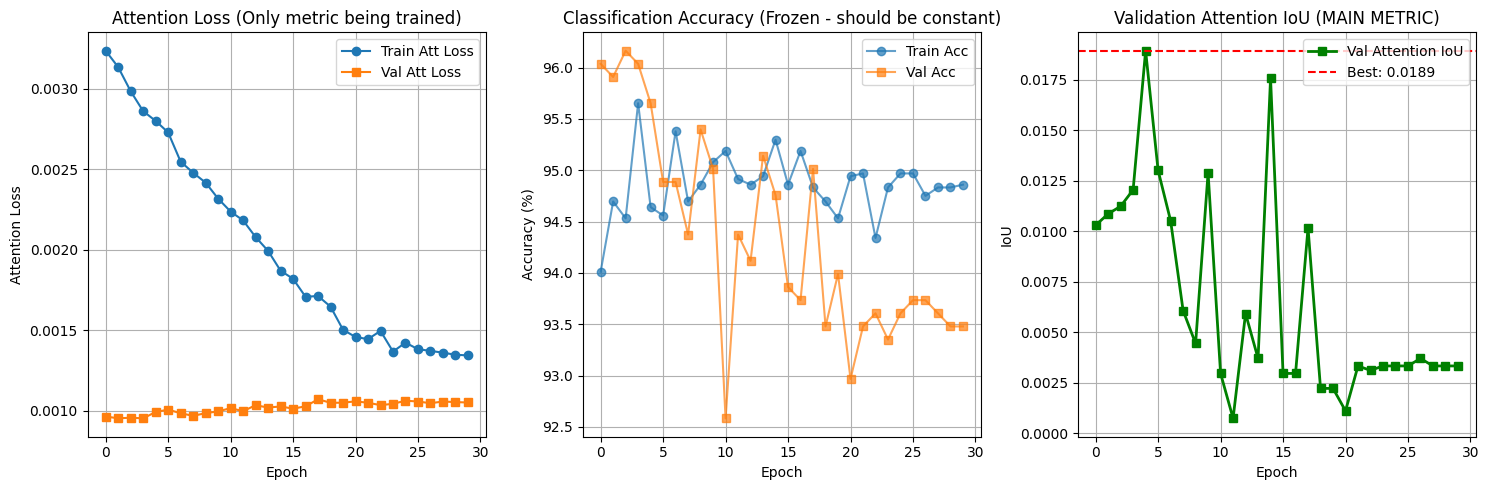

Training curves saved to 'wsod_attention_training_history.png'

Summary:
  Final Train Att Loss: 0.0013
  Final Val Att Loss: 0.0011
  Final Val IoU: 0.0033
  Best Val IoU: 0.0189
  Classification Acc (constant): 93.48%


In [26]:
# ============================================================================
# PLOT TRAINING HISTORY
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Attention Loss
axes[0].plot(history['train_att_loss'], label='Train Att Loss', marker='o')
axes[0].plot(history['val_att_loss'], label='Val Att Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Attention Loss')
axes[0].set_title('Attention Loss (Only metric being trained)')
axes[0].legend()
axes[0].grid(True)

# Accuracy (should stay constant - frozen classifier)
axes[1].plot(history['train_acc'], label='Train Acc', marker='o', alpha=0.7)
axes[1].plot(history['val_acc'], label='Val Acc', marker='s', alpha=0.7)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Classification Accuracy (Frozen - should be constant)')
axes[1].legend()
axes[1].grid(True)

# Attention IoU (main metric)
axes[2].plot(history['val_att_iou'], label='Val Attention IoU', marker='s', color='green', linewidth=2)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('IoU')
axes[2].set_title('Validation Attention IoU (MAIN METRIC)')
axes[2].axhline(y=best_val_iou, color='r', linestyle='--', label=f'Best: {best_val_iou:.4f}')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.savefig('wsod_attention_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print("Training curves saved to 'wsod_attention_training_history.png'")
print(f"\nSummary:")
print(f"  Final Train Att Loss: {history['train_att_loss'][-1]:.4f}")
print(f"  Final Val Att Loss: {history['val_att_loss'][-1]:.4f}")
print(f"  Final Val IoU: {history['val_att_iou'][-1]:.4f}")
print(f"  Best Val IoU: {best_val_iou:.4f}")
print(f"  Classification Acc (constant): {history['val_acc'][-1]:.2f}%")

In [28]:
# ============================================================================
# LOAD BEST MODEL FOR TESTING
# ============================================================================

print("\n" + "=" * 80)
print("Loading best model for testing...")
print("=" * 80)

checkpoint = torch.load(best_model_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']+1}")
print(f"Best val IoU: {checkpoint['val_att_iou']:.4f}")  # Changed from val_f1 to val_att_iou


Loading best model for testing...
Loaded best model from epoch 5
Best val IoU: 0.0189


In [30]:
# ============================================================================
# TEST SET EVALUATION
# ============================================================================

print("\nEvaluating on test set...")

# Define criterion for test evaluation
criterion = nn.CrossEntropyLoss()

test_loss, test_acc, test_preds, test_labels, test_probs, test_prec, test_recall, test_f1, test_auc = validate_wsod(
    model, test_loader, criterion, device
)

print("\n" + "=" * 80)
print("TEST SET RESULTS")
print("=" * 80)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")
print(f"Test AUC-ROC: {test_auc:.4f}")
print(f"Test Precision: {test_prec:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test F1 Score: {test_f1:.4f}")

# Confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(test_labels, test_preds)
print("\nConfusion Matrix:")
print(cm)


Evaluating on test set...


Validation: 100%|██████████| 50/50 [00:19<00:00,  2.54it/s]


TEST SET RESULTS
Test Loss: 0.1681
Test Accuracy: 94.14%
Test AUC-ROC: 0.9834
Test Precision: 0.9476
Test Recall: 0.8341
Test F1 Score: 0.8873

Confusion Matrix:
[[558  10]
 [ 36 181]]



Generating Attention Visualizations on Test Set
Selected random indices: [433 359 276 320 307 641]


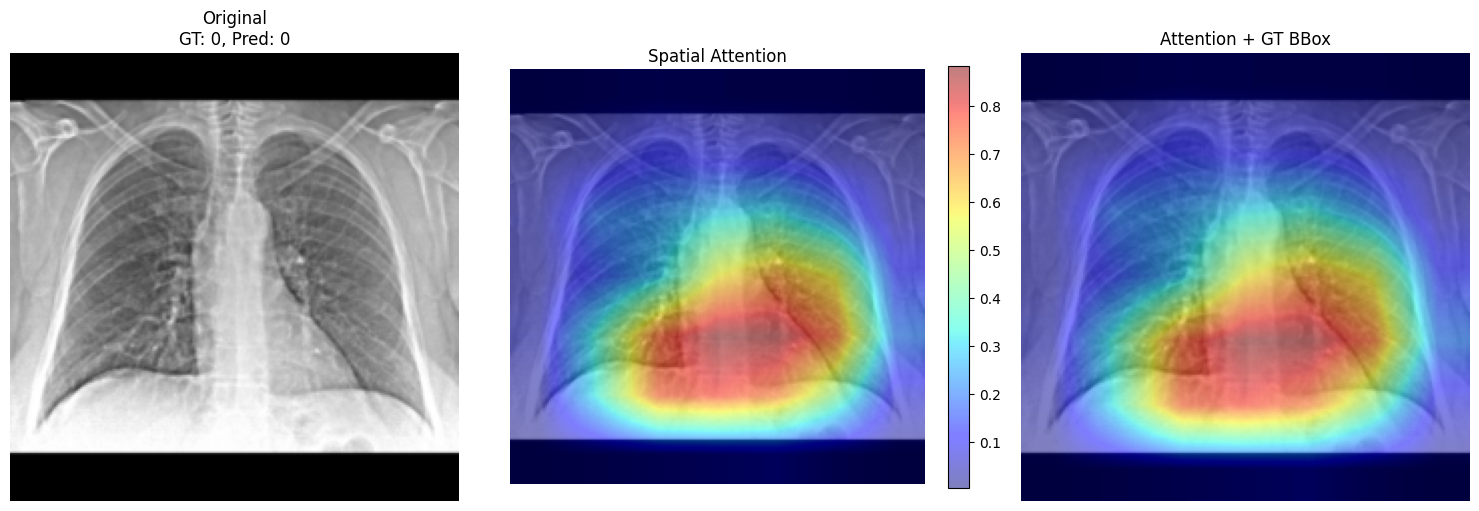

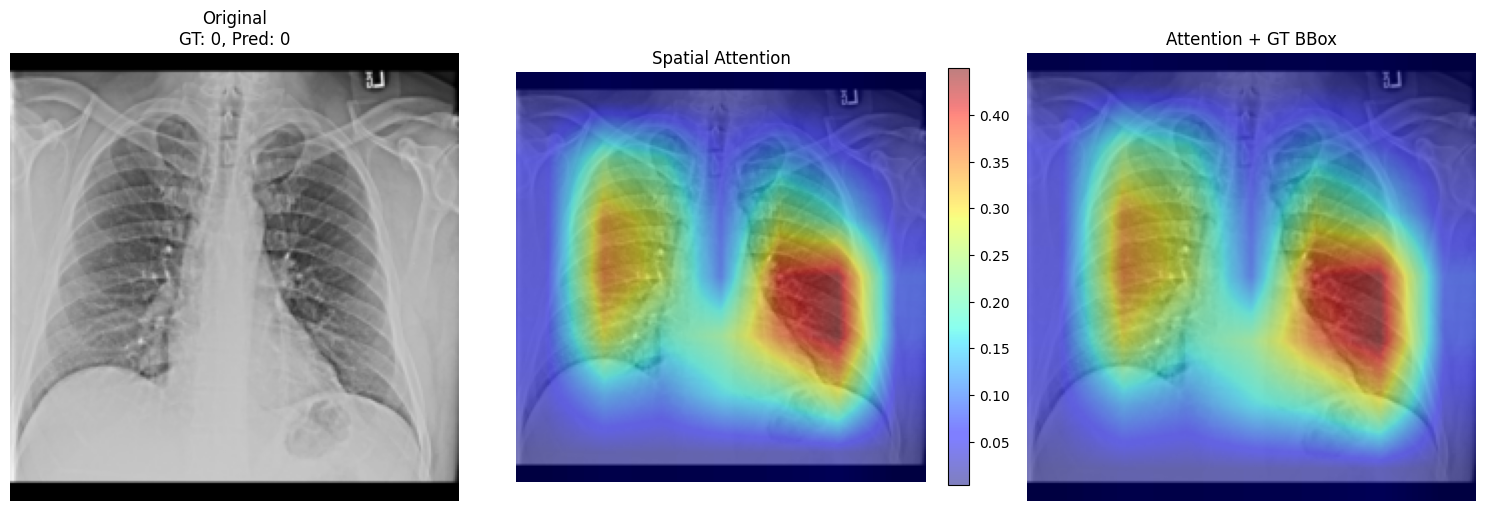

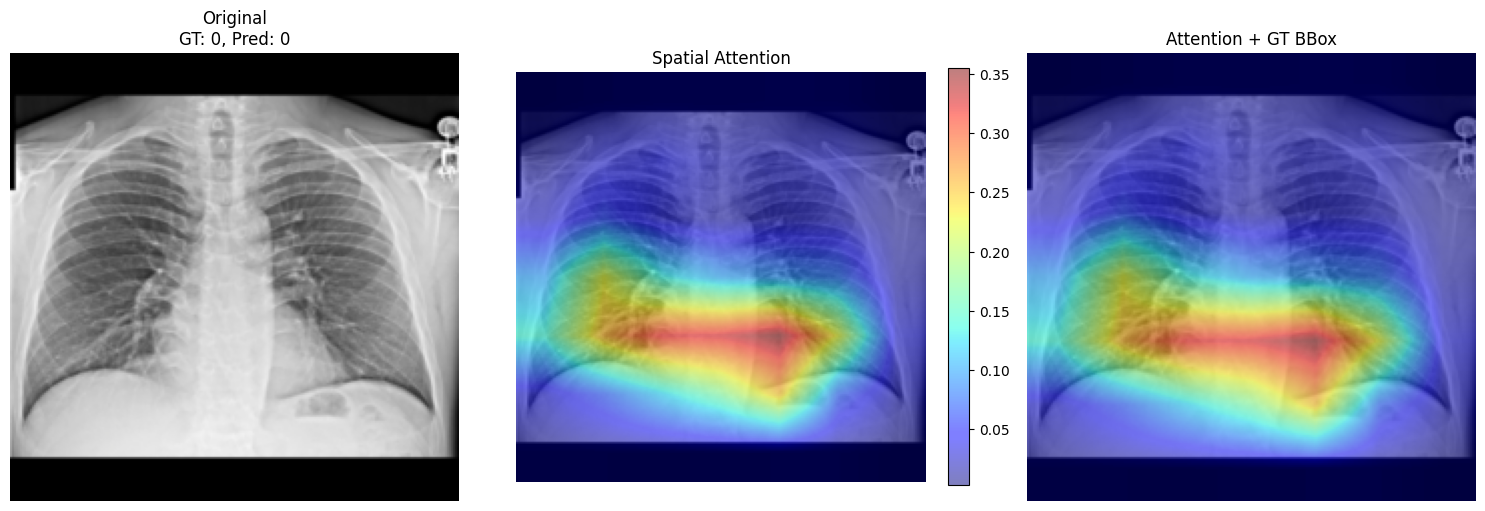

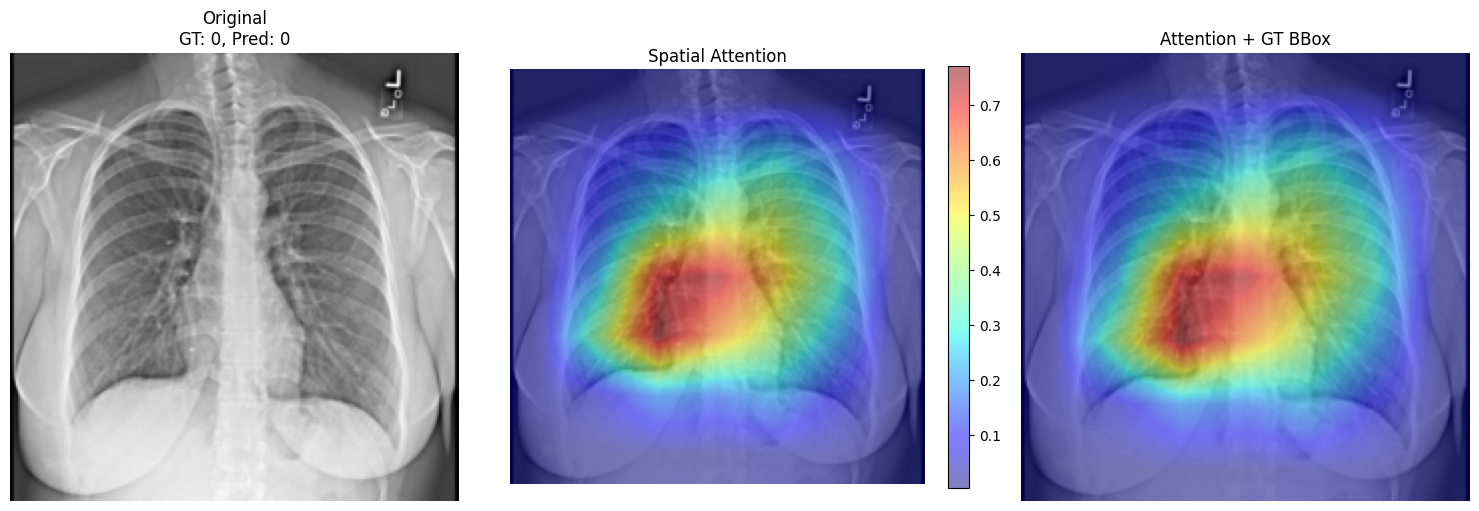

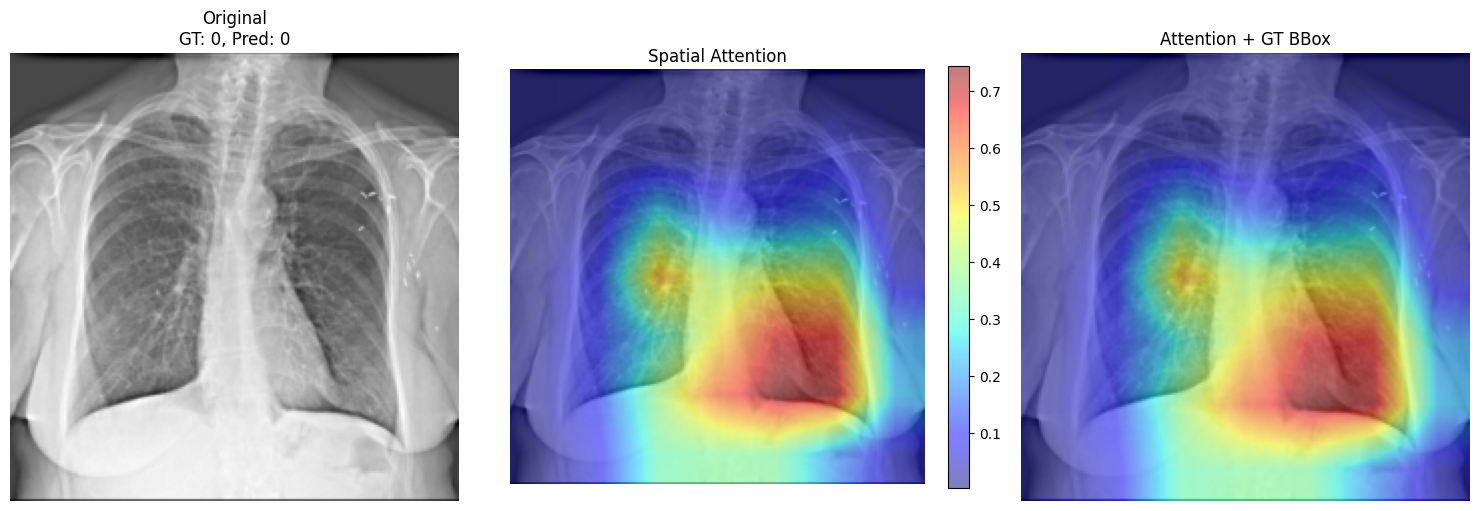

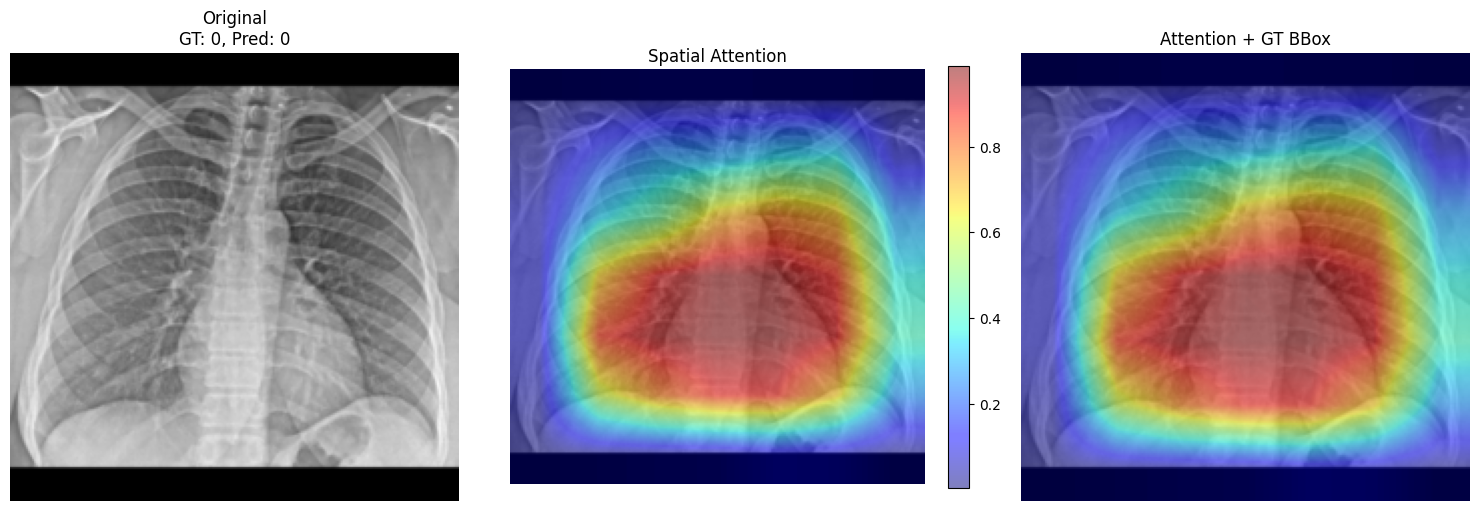


Visualized 6 random test samples with attention maps
Note: Images with multiple nodules will show one bbox per visualization


In [31]:
# ============================================================================
# VISUALIZE ATTENTION MAPS ON TEST SET
# ============================================================================

print("\n" + "=" * 80)
print("Generating Attention Visualizations on Test Set")
print("=" * 80)

model.eval()

# Get random samples from test dataset
num_samples = 6
random_indices = np.random.choice(len(test_dataset), size=num_samples, replace=False)

print(f"Selected random indices: {random_indices}")

for idx in random_indices:
    img, label, bbox = test_dataset[idx]
    
    # Get prediction
    with torch.no_grad():
        output = model(img.unsqueeze(0).to(device))
        pred = output.argmax(1).item()
    
    # Visualize
    subfig = visualize_attention_with_bbox(model, img, bbox, label, pred)
    plt.show()
    
print(f"\nVisualized {num_samples} random test samples with attention maps")
print("Note: Images with multiple nodules will show one bbox per visualization")



Finding positive samples (with nodules) for visualization...
Found 165 unique positive patients in test set
Visualizing 8 random positive patients...

Patient: n0884.mha
  Added bbox: pixel=[653, 421, 51, 42] -> norm=[0.638, 0.411, 0.050, 0.041]
Found 1 nodule(s)


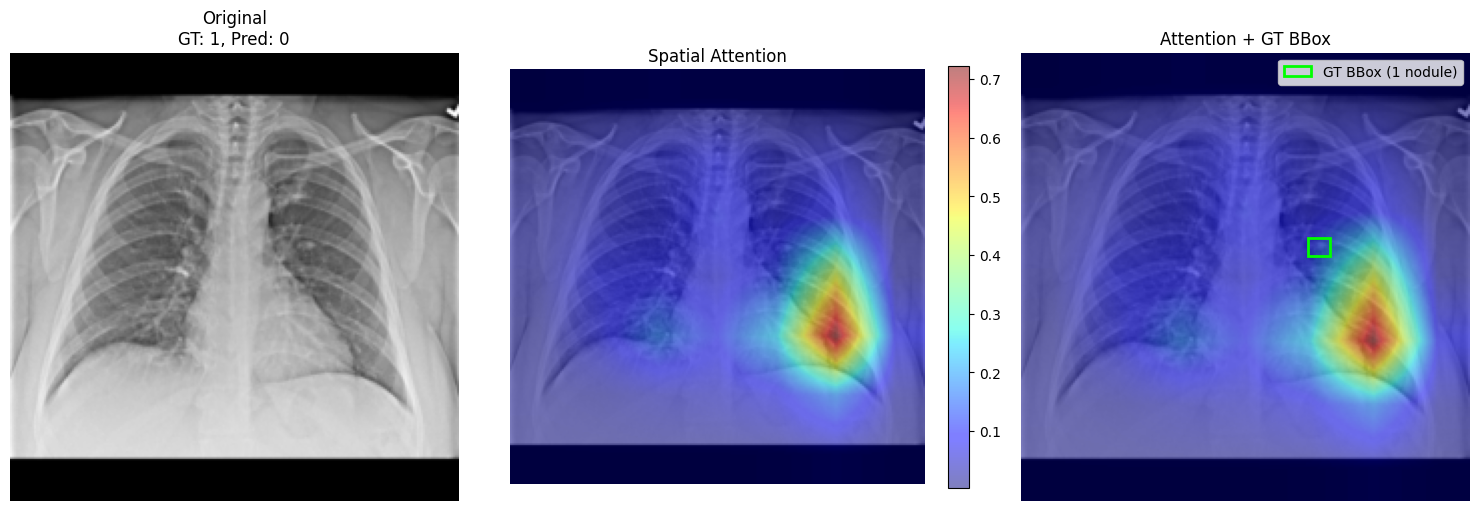


Patient: n1068.mha
  Added bbox: pixel=[791, 361, 50, 51] -> norm=[0.772, 0.353, 0.049, 0.050]
Found 1 nodule(s)


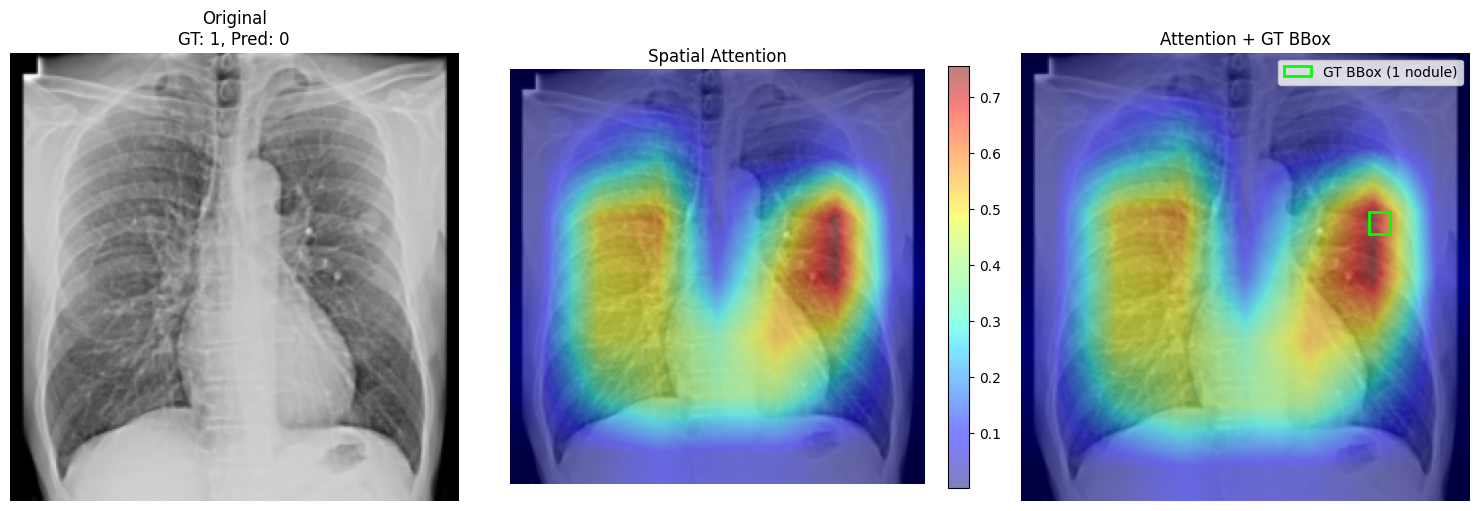


Patient: n0707.mha
  Added bbox: pixel=[191, 686, 28, 32] -> norm=[0.187, 0.670, 0.027, 0.031]
Found 1 nodule(s)


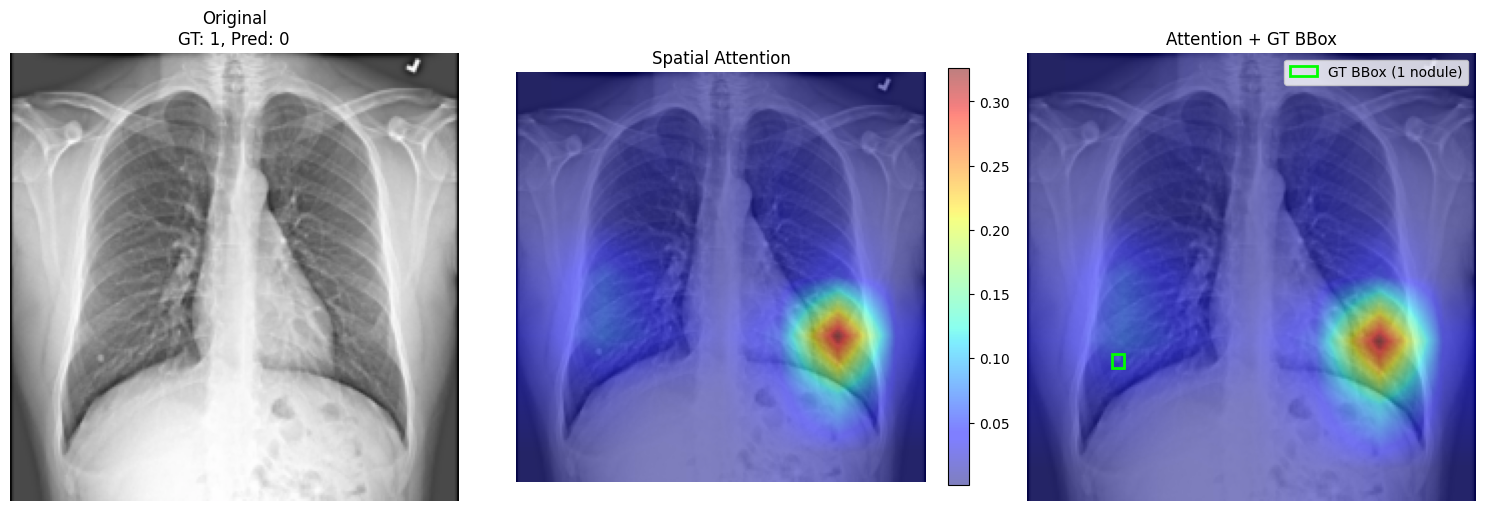


Patient: n0459.mha
  Added bbox: pixel=[232, 585, 50, 51] -> norm=[0.227, 0.571, 0.049, 0.050]
  Added bbox: pixel=[378, 668, 57, 55] -> norm=[0.369, 0.652, 0.056, 0.054]
Found 2 nodule(s)


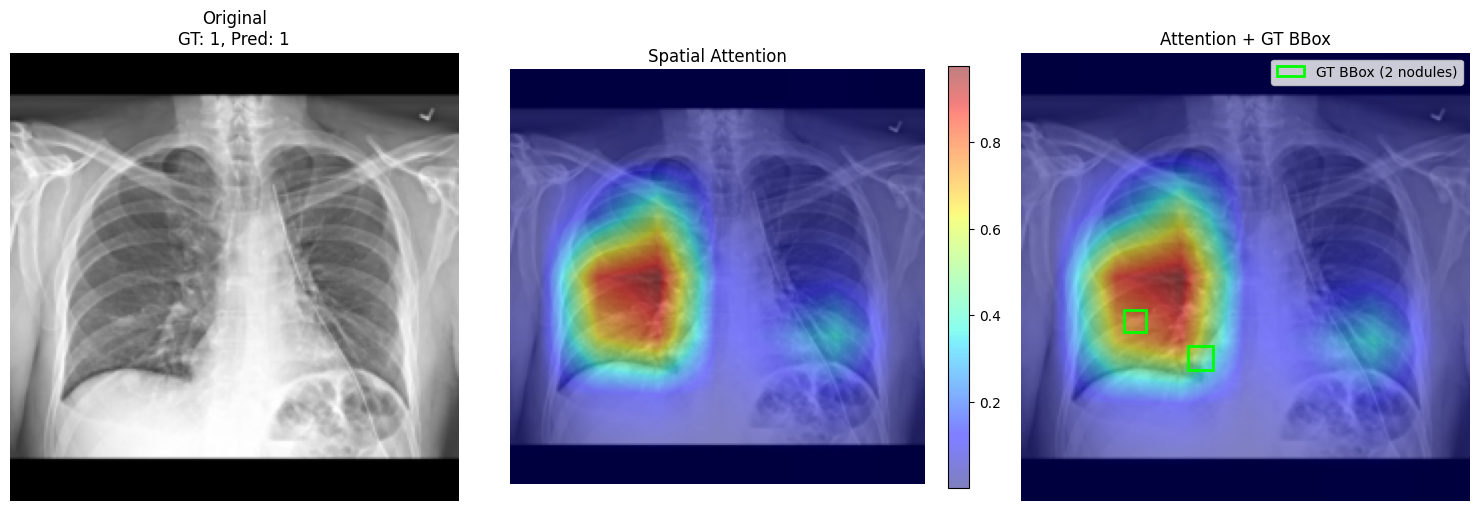


Patient: n0720.mha
  Added bbox: pixel=[211, 518, 60, 53] -> norm=[0.206, 0.506, 0.059, 0.052]
Found 1 nodule(s)


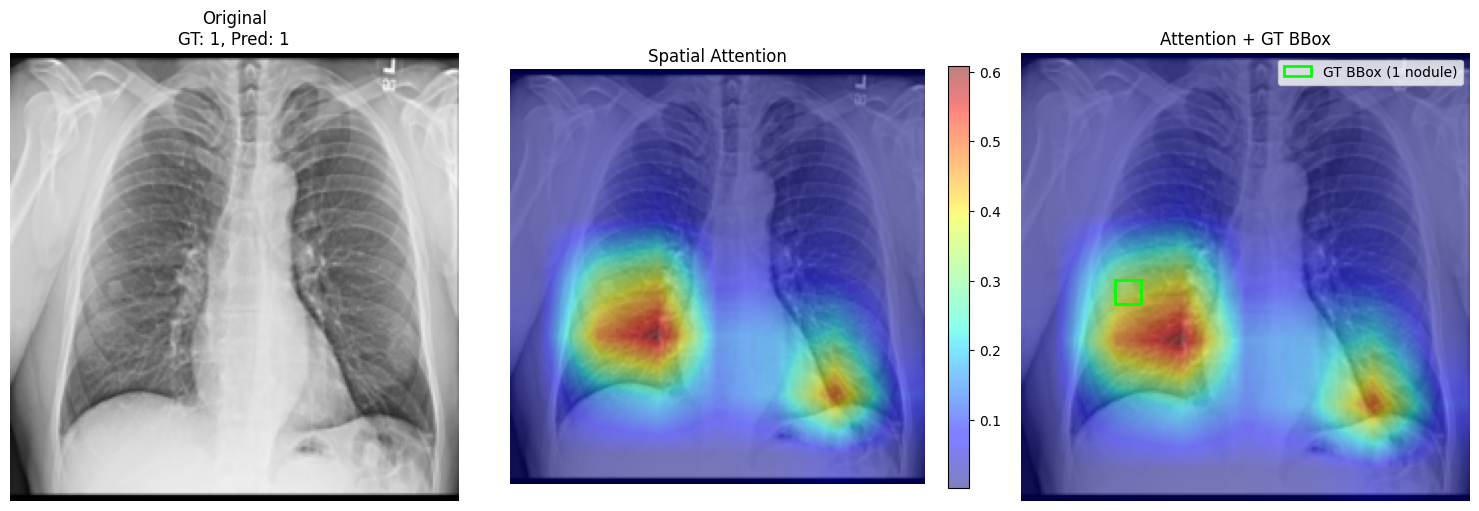


Patient: n0141.mha
  Added bbox: pixel=[361, 317, 89, 71] -> norm=[0.353, 0.310, 0.087, 0.069]
Found 1 nodule(s)


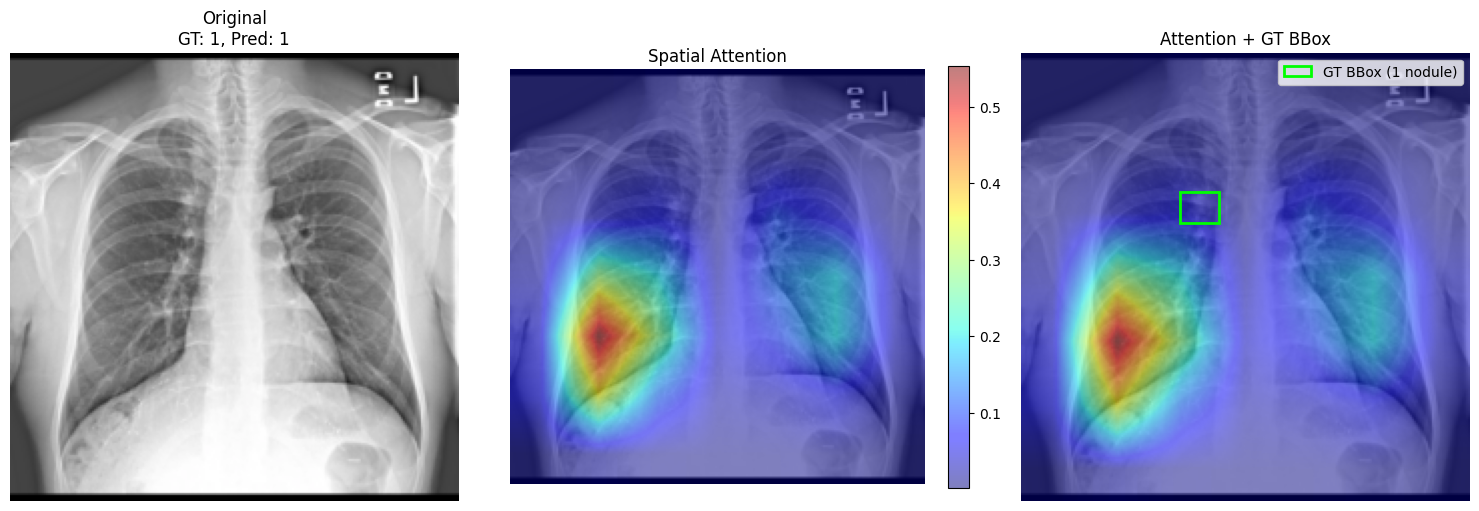


Patient: n0368.mha
  Added bbox: pixel=[175, 482, 38, 38] -> norm=[0.171, 0.471, 0.037, 0.037]
Found 1 nodule(s)


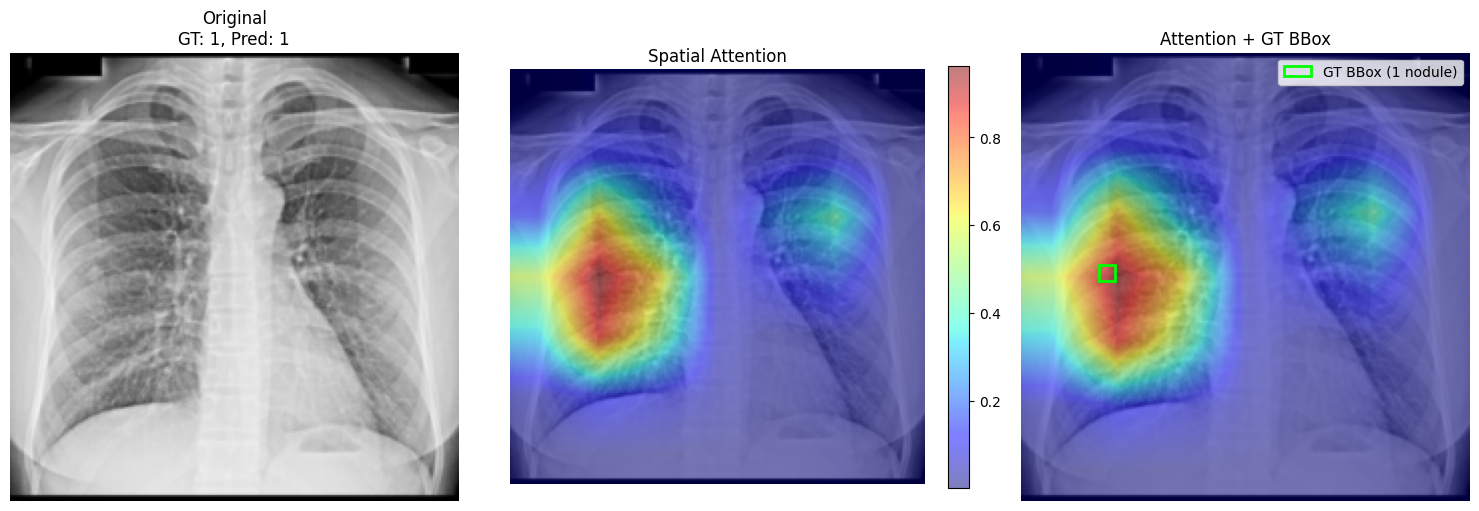


Patient: n0709.mha
  Added bbox: pixel=[686, 184, 92, 92] -> norm=[0.670, 0.180, 0.090, 0.090]
Found 1 nodule(s)


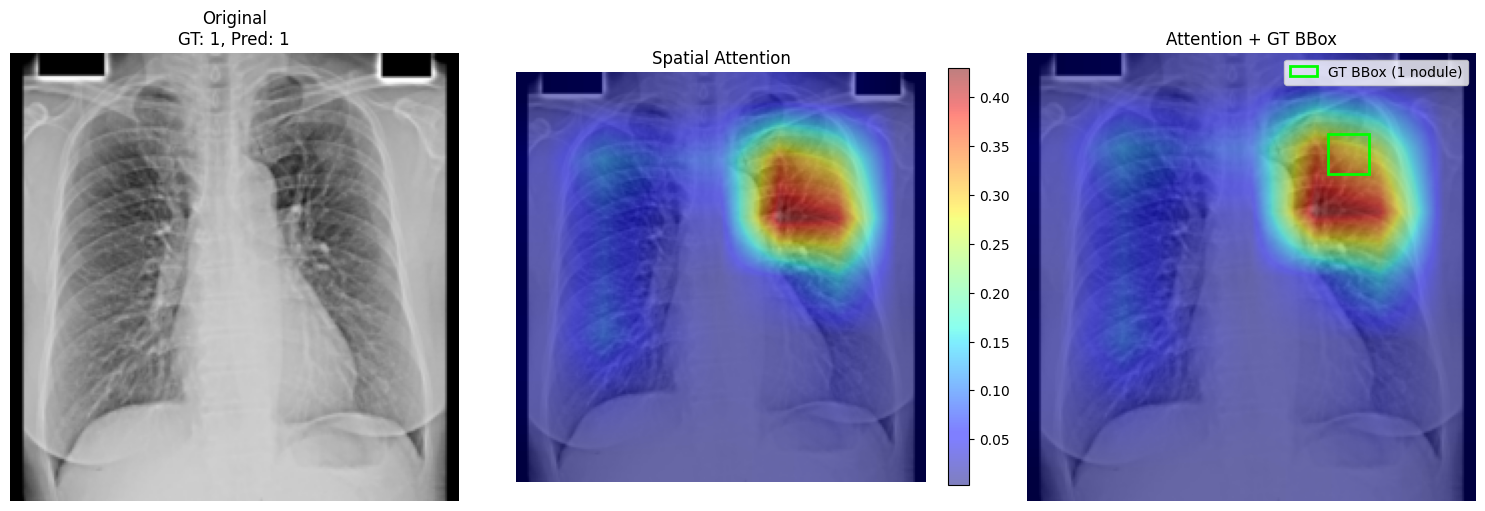


Displayed attention visualizations for 8 unique positive patients
Each visualization shows ALL nodules for that patient

WSOD Fine-tuning Complete!

Best model saved to: best_wsod_attention_resnet50.pth
Final Test AUC: 0.9834
Final Test F1: 0.8873


In [35]:
# ============================================================================
# VISUALIZE POSITIVE SAMPLES (NODULES) - WITH MULTIPLE BBOXES PER PATIENT
# ============================================================================

print("\nFinding positive samples (with nodules) for visualization...")

# Find unique positive patients (to avoid showing same patient multiple times)
positive_patients = {}  # {img_name: first_index}
for i in range(len(test_dataset)):
    _, label, _ = test_dataset[i]
    if label == 1:
        img_name = test_df.iloc[i]['img_name']
        if img_name not in positive_patients:
            positive_patients[img_name] = i

print(f"Found {len(positive_patients)} unique positive patients in test set")

# Randomly select up to 8 unique patients
num_vis = min(8, len(positive_patients))
if num_vis > 0:
    selected_patients = np.random.choice(list(positive_patients.keys()), size=num_vis, replace=False)
    print(f"Visualizing {num_vis} random positive patients...")
    
    for patient_name in selected_patients:
        # Get the first index for this patient
        idx = positive_patients[patient_name]
        img, label, _ = test_dataset[idx]
        
        print(f"\nPatient: {patient_name}")
        
        # Find ALL bboxes for this patient from the dataframe
        patient_rows = test_df[test_df['img_name'] == patient_name]
        all_bboxes = []
        
        # Get original image dimensions (assuming square images from your dataset)
        # You may need to adjust this based on your actual image dimensions
        if 'img_width' in patient_rows.columns and 'img_height' in patient_rows.columns:
            img_width = patient_rows.iloc[0]['img_width']
            img_height = patient_rows.iloc[0]['img_height']
        else:
            # Default assumption - adjust if needed
            img_width = 1024  # Typical X-ray width
            img_height = 1024  # Typical X-ray height
        
        for _, row in patient_rows.iterrows():
            if row['label'] == 1:
                # Normalize bbox coordinates to [0, 1]
                x_norm = row['x'] / img_width
                y_norm = row['y'] / img_height
                w_norm = row['width'] / img_width
                h_norm = row['height'] / img_height
                
                bbox_tensor = torch.tensor([
                    x_norm,
                    y_norm,
                    w_norm,
                    h_norm
                ], dtype=torch.float32)
                all_bboxes.append(bbox_tensor)
                print(f"  Added bbox: pixel=[{row['x']:.0f}, {row['y']:.0f}, {row['width']:.0f}, {row['height']:.0f}] -> norm=[{x_norm:.3f}, {y_norm:.3f}, {w_norm:.3f}, {h_norm:.3f}]")
        
        print(f"Found {len(all_bboxes)} nodule(s)")
        
        # Get prediction
        with torch.no_grad():
            output = model(img.unsqueeze(0).to(device))
            pred = output.argmax(1).item()
        
        # Visualize with ALL bboxes
        subfig = visualize_attention_with_bbox(model, img, all_bboxes, label, pred)
        plt.show()
    
    print(f"\n{'='*80}")
    print(f"Displayed attention visualizations for {num_vis} unique positive patients")
    print(f"Each visualization shows ALL nodules for that patient")
else:
    print("No positive samples found in test set")

print("\n" + "=" * 80)
print("WSOD Fine-tuning Complete!")
print("=" * 80)
print(f"\nBest model saved to: {best_model_path}")
print(f"Final Test AUC: {test_auc:.4f}")
print(f"Final Test F1: {test_f1:.4f}")